# Tutorial 6.1: scSLAT Registration of P22 Mouse Brain Adjacent H3K27ac and RNA Sections

This tutorial combines the H3K27ac histone-modification map from S2 with spatial RNA profiles from S3, two anatomically adjacent coronal sections from the P22 mouse brain spatial CUT&Tag-RNA-seq dataset reported by [Zhang et al.](https://doi.org/10.1038/s41586-023-05795-1). The experiment profiles spatial histone modifications and transcriptomes at near-single-cell resolution; the dataset is publicly available from [GEO under accession GSE205055](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE205055).

[SLAT](https://doi.org/10.1038/s41467-023-43105-5) provides the heterogeneous spatial registration used here. Its [official code](https://github.com/gao-lab/SLAT) and [documentation](https://slat.readthedocs.io/) describe the scSLAT implementation. High-confidence RNA-to-H3K27ac correspondences are projected into the S2 coordinate system to create the partially observed RNA-on-H3K27ac object analysed by PRISM in Tutorial 6.2.

Because the two layers originate from separate sections, they have no inherent cell-to-cell correspondence. Only cross-section pairs supported after confidence filtering are retained for the downstream incomplete-registration analysis.


### GLUE preparation

scSLAT begins from precomputed GLUE embeddings, which place RNA and H3K27ac profiles in a shared feature space before spatial registration. Users must prepare compatible `X_glue` embeddings in their own external GLUE/scSLAT environment, following the [GLUE documentation](https://scglue.readthedocs.io/) and [scSLAT tutorial](https://slat.readthedocs.io/en/latest/tutorials/basic_usage.html). PRISM does not distribute these inputs or a standalone GLUE-preparation workflow; this notebook begins at the registration stage.


In [41]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
from scSLAT.model import Cal_Spatial_Net, load_anndatas, run_SLAT, spatial_match
from scSLAT.viz import match_3D_multi

plt.rcParams.update({"font.size": 11, "axes.linewidth": 1.0, "pdf.fonttype": 42})

In [42]:
# Load prepared inputs
DATASET_DIR = Path("Datasets") / "P22 mouse brain_adjacent sections"
adata1 = sc.read_h5ad(DATASET_DIR / "S3_adata_RNA.h5ad")
adata2 = sc.read_h5ad(DATASET_DIR / "S2_adata_ATAC.h5ad")

Both AnnData objects store the precomputed cross-modality GLUE representation in `obsm["X_glue"]`, which scSLAT uses for registration. Their `obs["mclust"]` columns store the mclust cluster label for each spatial location; these labels are used only to colour and display spatial domains in the subsequent 3D alignment visualization and do not affect the alignment procedure.

In [43]:
adata1

AnnData object with n_obs × n_vars = 9398 × 22731
    obs: 'mclust'
    obsm: 'X_glue', 'X_pca', 'spatial'

In [44]:
# Build spatial graphs
Cal_Spatial_Net(adata1, k_cutoff=20, model="KNN")
Cal_Spatial_Net(adata2, k_cutoff=20, model="KNN")

Calculating spatial neighbor graph ...
The graph contains 193856 edges, 9398 cells.
20.62736752500532 neighbors per cell on average.
Calculating spatial neighbor graph ...
The graph contains 190684 edges, 9230 cells.
20.659154929577465 neighbors per cell on average.


In [45]:
# Run SLAT with the precomputed GLUE representation
edges, features = load_anndatas([adata1, adata2], feature="glue")
embd0, embd1, elapsed_time = run_SLAT(features, edges, LGCN_layer=6, hidden_size=4096)

Use glue feature to format graph
Choose GPU:5 as device
Running
Training model time: 1.52


In [46]:
# Match H3K27ac locations to RNA: store SLAT embeddings and find cross-section pairs
def to_numpy_embedding(embedding):
    return embedding.detach().cpu().numpy() if torch.is_tensor(embedding) else np.asarray(embedding)

adata1.obsm["X_slat"] = to_numpy_embedding(embd0).astype(np.float32, copy=False)
adata2.obsm["X_slat"] = to_numpy_embedding(embd1).astype(np.float32, copy=False)
best, index, distance = spatial_match([embd0, embd1], adatas=[adata1, adata2], reorder=False,
                                      smooth_range=200)
label_key = "mclust"
adata1_df = pd.DataFrame({"index": np.arange(embd0.shape[0]), "x": adata1.obsm["spatial"][:, 0],
                          "y": adata1.obsm["spatial"][:, 1], label_key: adata1.obs[label_key]})
adata2_df = pd.DataFrame({"index": np.arange(embd1.shape[0]), "x": adata2.obsm["spatial"][:, 0],
                          "y": adata2.obsm["spatial"][:, 1], label_key: adata2.obs[label_key]})
matching = np.array([np.arange(index.shape[0]), best])
best_match = distance[:, 0]

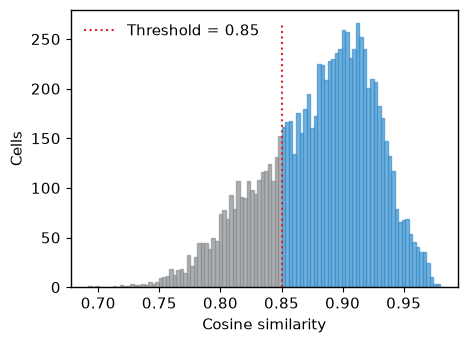

In [71]:
# Inspect matching similarity
MATCH_THRESHOLD = 0.85
fig, ax = plt.subplots(figsize=(5, 3.6))
n, bins, patches = ax.hist(distance[:, 0], bins=100, edgecolor="#8C9093", alpha=0.7)
for left, right, patch in zip(bins[:-1], bins[1:], patches):
    if 0.5 * (left + right) < MATCH_THRESHOLD:
        patch.set_facecolor("#8C9093")
        patch.set_edgecolor("#8C9093")
    else:
        patch.set_facecolor("#3990CE")
        patch.set_edgecolor("#3990CE")
ax.vlines(MATCH_THRESHOLD, 0, n.max(), color="#d62728", linestyles="dotted",
          label=f"Threshold = {MATCH_THRESHOLD:.2f}")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Cells")
ax.grid(False)
ax.legend(frameon=False)
plt.show()

The score distribution is used to choose the threshold that separates retained registrations from low-confidence correspondences.


### Retain high-confidence registrations

Only correspondences above the selected score threshold are treated as retained RNA-H3K27ac pairs.


In [ ]:
# Filter high-confidence pairs
matching_filter = matching[:, distance[:, 0] > MATCH_THRESHOLD]
print(f"High-confidence pairs: {matching_filter.shape[1]:,} / {adata2.n_obs:,}")

High-confidence pairs: 6,902 / 9,230


dataset1: 12 cell types; dataset2: 12 cell types;
                    Total :12 celltypes; Overlap: 12 cell types
                    Not overlap :[[]]
Subsampled 300 pairs from 6902


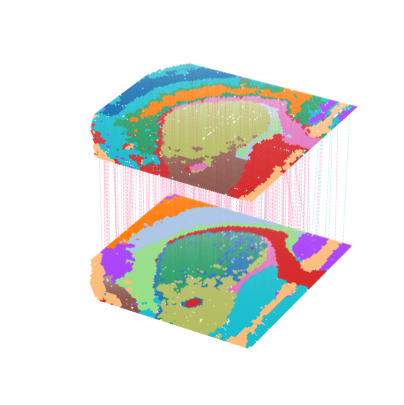

In [ ]:
# Inspect RNA-H3K27ac registration in 3D
multi_align = match_3D_multi(adata1_df, adata2_df, matching_filter, meta=label_key, rotate=["y", "y"],
                             scale_coordinate=True, subsample_size=300)
multi_align.draw_3D([5, 5], line_width=0.5, point_size=[1, 0.5], hide_axis=True, show_error=True)

The 3D display provides a qualitative check that retained RNA-H3K27ac correspondences align across the adjacent sections.


### Build registered RNA-on-H3K27ac data

The output follows the S2 H3K27ac coordinate order. H3K27ac locations without a retained RNA partner receive zero RNA values and `missing="0"`, producing the real incomplete target object for Tutorial 6.2.


In [ ]:
# Create and save the H3K27ac-ordered registered RNA object
# Rows follow original S2 H3K27ac locations; unregistered locations receive zero RNA values.
target_idx = matching_filter[0].astype(int)
align_idx = matching_filter[1].astype(int)
matched_expression = adata1[align_idx, :].X
if not sp.issparse(matched_expression):
    matched_expression = sp.csr_matrix(np.asarray(matched_expression, dtype=np.float32))
else:
    matched_expression = matched_expression.tocsr().astype(np.float32)
matched_expression = matched_expression.tocoo()
full_X = sp.csr_matrix((matched_expression.data,
    (target_idx[matched_expression.row], matched_expression.col)), shape=(adata2.n_obs, adata1.n_vars),
    dtype=np.float32)
full_obs = adata2.obs.copy()
full_obs["missing"] = "0"
full_obs["matched_RNA_barcode"] = "NA"
full_obs["SLAT_score"] = np.nan
full_obs.loc[adata2.obs_names[target_idx], "missing"] = "1"
full_obs.loc[adata2.obs_names[target_idx], "matched_RNA_barcode"] = adata1.obs_names.to_numpy()[align_idx]
full_obs.loc[adata2.obs_names[target_idx], "SLAT_score"] = best_match[target_idx]
new_adata_full = ad.AnnData(X=full_X, obs=full_obs, var=adata1.var.copy())
new_adata_full.obs_names = adata2.obs_names.copy()
new_adata_full.obsm["spatial"] = adata2.obsm["spatial"].copy()
new_adata_full.uns["registration"] = {"method": "scSLAT", "reference": "S3 RNA", "query": "S2 H3K27ac (spatial CUT&Tag)",
                                       "similarity_threshold": MATCH_THRESHOLD}
new_adata_full.write_h5ad(DATASET_DIR / "S3_adata_RNA_reg.h5ad")

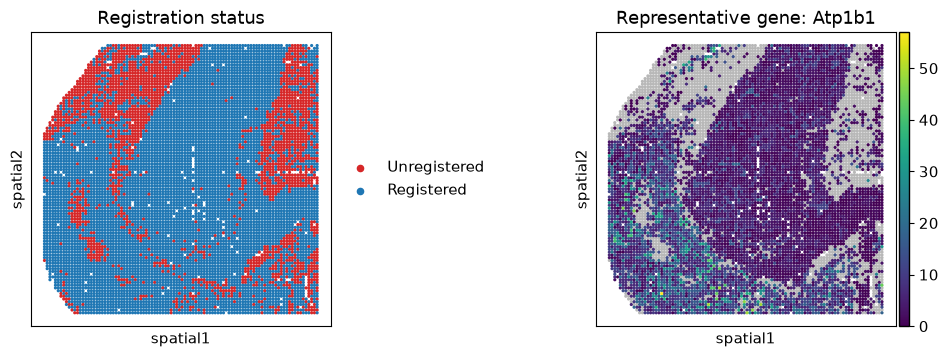

In [53]:
# Display real registration missingness and transferred RNA expression
new_adata_full.uns["missing_colors"] = ["#d62728", "#1f77b4"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
sc.pl.embedding(new_adata_full, basis="spatial", color="missing", ax=axes[0], title="Registration status",
    size=21, legend_loc="right margin", show=False)
legend = axes[0].get_legend()
for text, label in zip(legend.get_texts(), ["Unregistered", "Registered"]):
    text.set_text(label)
for handle in getattr(legend, "legend_handles", getattr(legend, "legendHandles", [])):
    if hasattr(handle, "set_sizes"):
        handle.set_sizes([20.0])
sc.pl.embedding(new_adata_full, basis="spatial", color="Atp1b1", ax=axes[1],
    title="Representative gene: Atp1b1", size=21, cmap="viridis",
    mask_obs=new_adata_full.obs["missing"].astype(str) == "1", na_color="#B8B8B8", show=False)
for ax in axes:
    ax.set_xlabel("spatial1")
    ax.set_ylabel("spatial2")
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
plt.subplots_adjust(left=0.05, right=0.98, bottom=0.15, top=0.85, wspace=0.55)
plt.show()

The final panels show retained and unregistered S2 locations together with an example transferred RNA feature.
